In [1]:
from google.colab import files

uploaded = files.upload()

Saving APL_Logistics.csv to APL_Logistics.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('APL_Logistics.csv', encoding='latin1')

In [4]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [5]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Segment', 'Customer State', 'Customer Street',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'Shipping Mode'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [7]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [8]:
df.dropna(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180508 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180508 non-null  object 
 1   Days for shipping (real)       180508 non-null  int64  
 2   Days for shipment (scheduled)  180508 non-null  int64  
 3   Benefit per order              180508 non-null  float64
 4   Sales per customer             180508 non-null  float64
 5   Delivery Status                180508 non-null  object 
 6   Late_delivery_risk             180508 non-null  int64  
 7   Category Id                    180508 non-null  int64  
 8   Category Name                  180508 non-null  object 
 9   Customer City                  180508 non-null  object 
 10  Customer Country               180508 non-null  object 
 11  Customer Fname                 180508 non-null  object 
 12  Customer Id                    1805

In [11]:
df["Order Region"] = df["Order Region"].str.strip()
df["Market"] = df["Market"].str.strip()

In [12]:
print(df["Order Region"].unique())
print(df["Market"].unique())

['South Asia' 'Central America' 'East of USA' 'Southern Europe'
 'Western Europe' 'Oceania' 'South America' 'West Asia' 'West Africa'
 'Caribbean' 'US Center' 'Central Africa' 'Southeast Asia'
 'Northern Europe' 'Eastern Asia' 'South of  USA' 'Southern Africa'
 'West of USA' 'Eastern Europe' 'Canada' 'East Africa' 'North Africa'
 'Central Asia']
['Pacific Asia' 'LATAM' 'USCA' 'Europe' 'Africa']


In [13]:
actual_col = "Days for shipping (real)"
scheduled_col = "Days for shipment (scheduled)"

In [14]:
df[actual_col].describe()

,Days for shipping (real)
count,180508.000000
mean,3.497673
std,1.623743
min,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,6.000000


In [15]:
df[scheduled_col].describe()

,Days for shipment (scheduled)
count,180508.000000
mean,2.931837
std,1.374457
min,0.000000
25%,2.000000
50%,4.000000
75%,4.000000
max,4.000000


In [16]:
sorted(df[actual_col].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6)]

In [17]:
sorted(df[scheduled_col].unique())

[np.int64(0), np.int64(1), np.int64(2), np.int64(4)]

In [18]:
df[df[actual_col] < 0]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode


In [19]:
df[df[scheduled_col] < 0]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode


In [20]:
df["Delay Gap"] = (df[actual_col] - df[scheduled_col])

In [21]:
print(df["Delay Gap"].describe())

count    180508.000000
mean          0.565836
std           1.490976
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Delay Gap, dtype: float64


In [23]:
def classify_delivery(delay):
    if delay < 0:
        return "Early"
    elif delay == 0:
        return "On-time"
    else:
        return "Delayed"


df["Delivery Timing"] = df["Delay Gap"].apply(classify_delivery)

In [24]:
df["Delivery Timing"].value_counts()

,count
Delivery Timing,
Delayed,103395
Early,43363
On-time,33750


In [25]:
df["Delivery Timing"].value_counts(normalize=True).mul(100).round(2)

,proportion
Delivery Timing,
Delayed,57.28
Early,24.02
On-time,18.70


In [29]:
on_time_percentage = ((df["Delivery Timing"] == "On-time").sum() / len(df)) * 100

In [30]:
on_time_percentage

np.float64(18.6972322556341)

In [31]:
risk_distribution = (
    df["Late_delivery_risk"]
    .value_counts()
    .sort_index()
)

In [32]:
risk_percentage = (
    df["Late_delivery_risk"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

In [33]:
risk_analysis = pd.DataFrame({
    "Count": risk_distribution,
    "Percentage": risk_percentage.round(2)
})

In [34]:
risk_analysis.index = ["No Risk (0)", "Late Risk (1)"]

risk_analysis

,Count,Percentage
No Risk (0),81536,45.17
Late Risk (1),98972,54.83


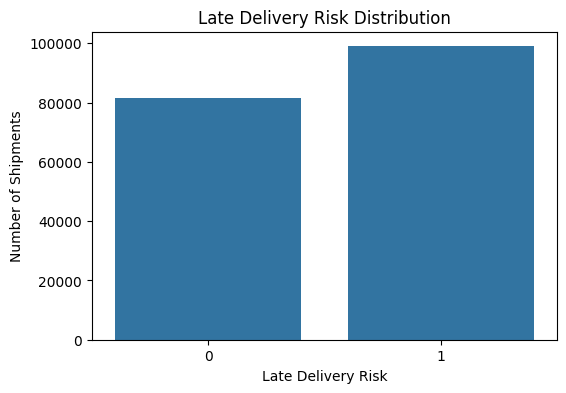

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Late_delivery_risk"
)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Shipments")
plt.show()

In [36]:
baseline_performance = {
    "Total Shipments": len(df),
    "On-Time Delivery (%)": (df["Delivery Timing"] == "On-time").mean() * 100,
    "Delayed Delivery (%)": (df["Delivery Timing"] == "Delayed").mean() * 100,
    "Early Delivery (%)": (df["Delivery Timing"] == "Early").mean() * 100,
    "Average Delivery Delay (Days)": df["Delay Gap"].mean(),
    "Late Delivery Risk (%)": df["Late_delivery_risk"].mean() * 100
}

In [37]:
baseline_df = pd.DataFrame(
    baseline_performance.items(),
    columns=["Metric", "Value"]
)

In [38]:
baseline_df["Value"] = baseline_df["Value"].round(2)

baseline_df

,Metric,Value
0,Total Shipments,180508.00
1,On-Time Delivery (%),18.70
2,Delayed Delivery (%),57.28
3,Early Delivery (%),24.02
4,Average Delivery Delay (Days),0.57
5,Late Delivery Risk (%),54.83


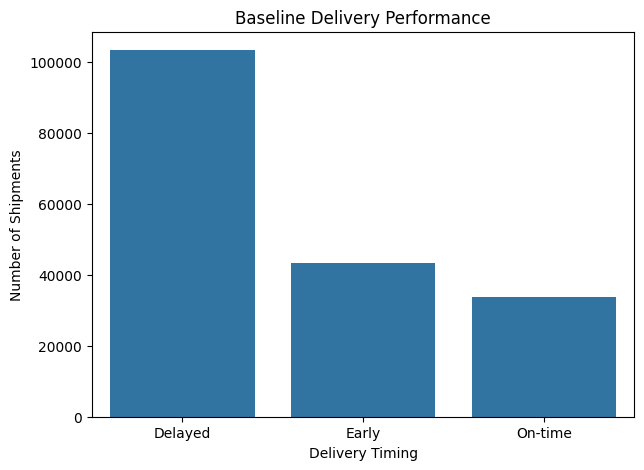

In [39]:
plt.figure(figsize=(7, 5))

timing_counts = df["Delivery Timing"].value_counts()

sns.barplot(
    x=timing_counts.index,
    y=timing_counts.values
)

plt.title("Baseline Delivery Performance")
plt.xlabel("Delivery Timing")
plt.ylabel("Number of Shipments")
plt.show()

In [40]:
shipping_mode_delay = (
    df.groupby("Shipping Mode")["Delay Gap"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
)

shipping_mode_delay

,mean,median,min,max
Shipping Mode,,,,
Second Class,1.99,2.0,0,4
First Class,1.00,1.0,1,1
Same Day,0.48,0.0,0,1
Standard Class,-0.00,0.0,-2,2


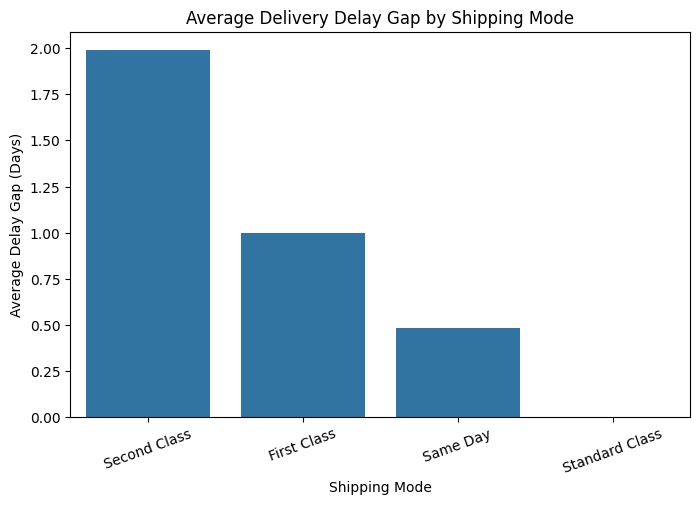

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=shipping_mode_delay.reset_index(),
    x="Shipping Mode",
    y="mean"
)

plt.title("Average Delivery Delay Gap by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay Gap (Days)")
plt.xticks(rotation=20)
plt.show()

In [42]:
delivery_status_delay = (
    df.groupby("Delivery Status")["Delay Gap"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
)

delivery_status_delay

,mean,median,min,max
Delivery Status,,,,
Late delivery,1.62,1.0,1,4
Shipping canceled,0.57,1.0,-2,4
Shipping on time,0.00,0.0,0,0
Advance shipping,-1.50,-2.0,-2,-1


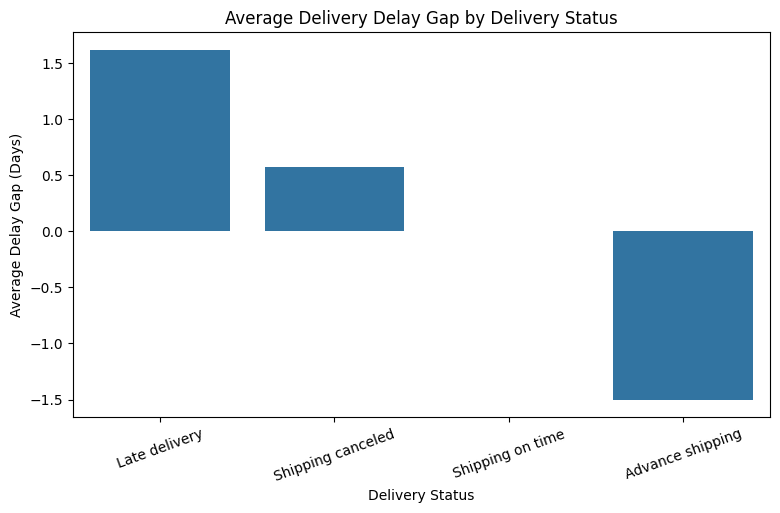

In [43]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=delivery_status_delay.reset_index(),
    x="Delivery Status",
    y="mean"
)

plt.title("Average Delivery Delay Gap by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Delay Gap (Days)")
plt.xticks(rotation=20)
plt.show()

In [44]:
shipping_mode_delay_frequency = (
    df.groupby("Shipping Mode")
    .agg(
        Total_Shipments=("Shipping Mode", "size"),
        Delayed_Shipments=("Delivery Timing", lambda x: (x == "Delayed").sum())
    )
)

In [45]:
shipping_mode_delay_frequency["Delay Frequency (%)"] = (
    shipping_mode_delay_frequency["Delayed_Shipments"]
    / shipping_mode_delay_frequency["Total_Shipments"]
    * 100
)

In [46]:
shipping_mode_delay_frequency = (
    shipping_mode_delay_frequency
    .sort_values("Delay Frequency (%)", ascending=False)
    .round(2)
)

In [47]:
shipping_mode_delay_frequency

,Total_Shipments,Delayed_Shipments,Delay Frequency (%)
Shipping Mode,,,
First Class,27812,27812,100.00
Second Class,35214,28077,79.73
Same Day,9737,4657,47.83
Standard Class,107745,42849,39.77


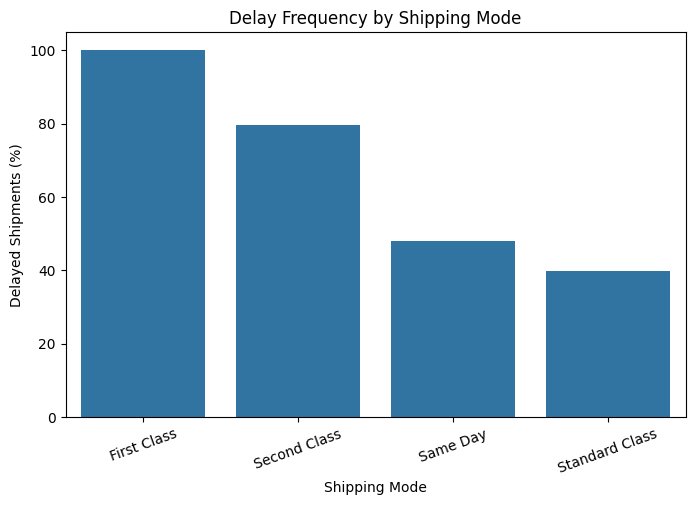

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=shipping_mode_delay_frequency.reset_index(),
    x="Shipping Mode",
    y="Delay Frequency (%)"
)

plt.title("Delay Frequency by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Delayed Shipments (%)")
plt.xticks(rotation=20)
plt.show()

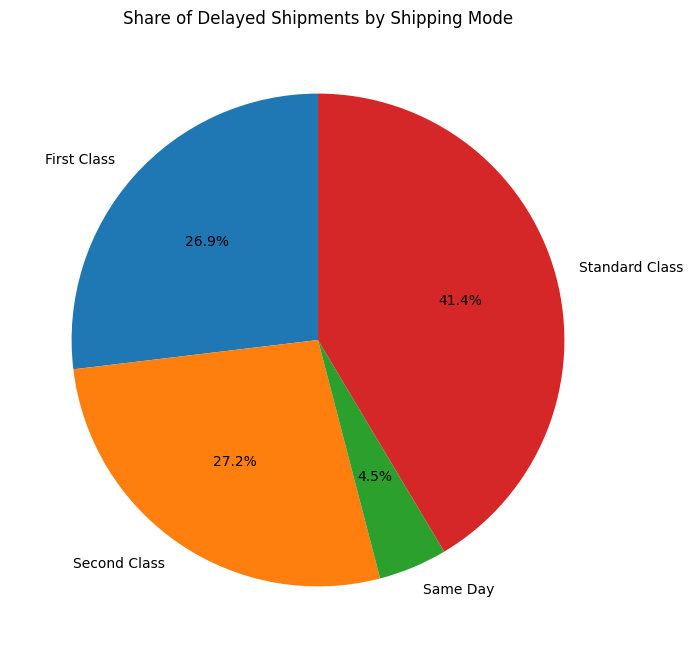

In [51]:
plt.figure(figsize=(8, 8))

plt.pie(
    shipping_mode_delay_frequency["Delayed_Shipments"],
    labels=shipping_mode_delay_frequency.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Share of Delayed Shipments by Shipping Mode")
plt.show()

In [52]:
region_delay = (
    df.groupby("Order Region")
    .agg(
        Total_Shipments=("Order Region", "size"),
        Delayed_Shipments=("Delivery Timing", lambda x: (x == "Delayed").sum())
    )
)

In [53]:
region_delay["Delay Frequency (%)"] = (
    region_delay["Delayed_Shipments"]
    / region_delay["Total_Shipments"]
    * 100
)

In [54]:
region_delay = (
    region_delay
    .sort_values("Delay Frequency (%)", ascending=False)
    .round(2)
)

region_delay

,Total_Shipments,Delayed_Shipments,Delay Frequency (%)
Order Region,,,
Central Africa,1677,1018,60.70
Western Europe,27107,15862,58.52
South Asia,7730,4523,58.51
South of USA,4045,2350,58.10
Southeast Asia,9535,5529,57.99
East of USA,6915,4009,57.98
West Asia,6009,3455,57.50
East Africa,1852,1064,57.45
Eastern Europe,3920,2252,57.45


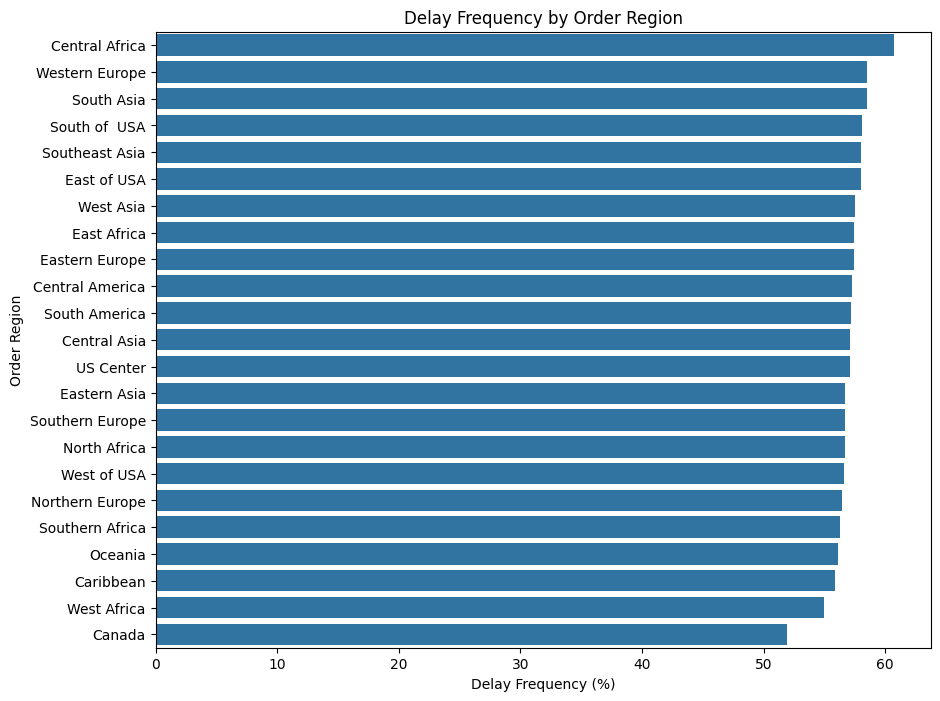

In [55]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=region_delay.reset_index(),
    y="Order Region",
    x="Delay Frequency (%)"
)

plt.title("Delay Frequency by Order Region")
plt.xlabel("Delay Frequency (%)")
plt.ylabel("Order Region")
plt.show()

In [56]:
country_delay = (
    df.groupby("Order Country")
    .agg(
        Total_Shipments=("Order Country", "size"),
        Delayed_Shipments=("Delivery Timing", lambda x: (x == "Delayed").sum())
    )
)

In [57]:
country_delay["Delay Frequency (%)"] = (
    country_delay["Delayed_Shipments"]
    / country_delay["Total_Shipments"]
    * 100
)

In [58]:
country_delay = (
    country_delay
    .sort_values("Delay Frequency (%)", ascending=False)
    .round(2)
)

country_delay

,Total_Shipments,Delayed_Shipments,Delay Frequency (%)
Order Country,,,
Bután,5,5,100.0
Armenia,5,5,100.0
Guinea Ecuatorial,2,2,100.0
Eritrea,2,2,100.0
República de Gambia,5,5,100.0
...,...,...,...
Burundi,1,0,0.0
Kuwait,2,0,0.0
Omán,8,0,0.0


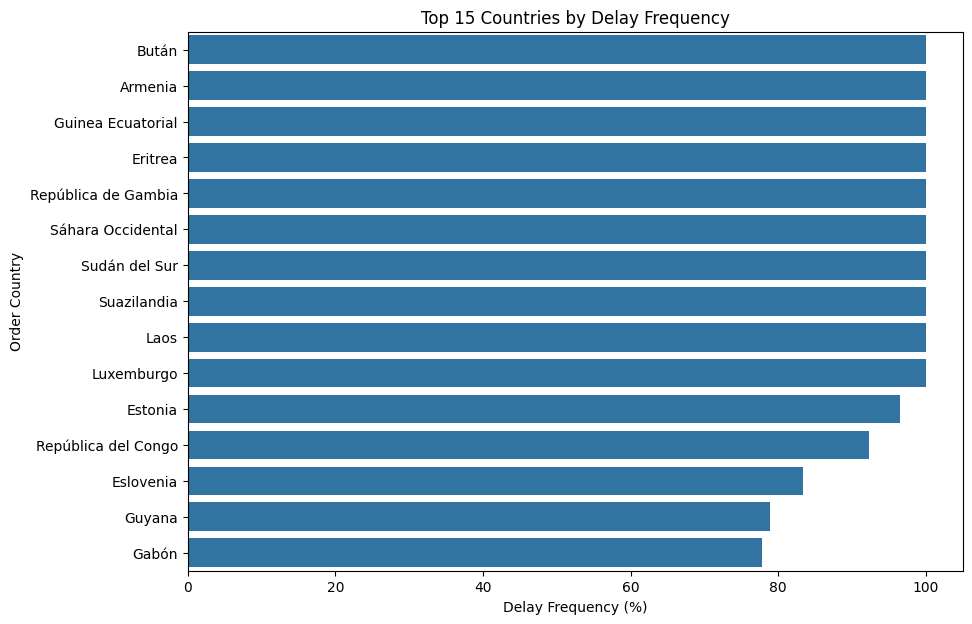

In [59]:
top_countries = country_delay.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_countries.reset_index(),
    y="Order Country",
    x="Delay Frequency (%)"
)

plt.title("Top 15 Countries by Delay Frequency")
plt.xlabel("Delay Frequency (%)")
plt.ylabel("Order Country")
plt.show()

In [60]:
market_delay = (
    df.groupby("Market")
    .agg(
        Total_Shipments=("Market", "size"),
        Delayed_Shipments=("Delivery Timing", lambda x: (x == "Delayed").sum())
    )
)

In [61]:
market_delay["Delay Frequency (%)"] = (
    market_delay["Delayed_Shipments"]
    / market_delay["Total_Shipments"]
    * 100
)

In [62]:
market_delay = (
    market_delay
    .sort_values("Delay Frequency (%)", ascending=False)
    .round(2)
)

market_delay

,Total_Shipments,Delayed_Shipments,Delay Frequency (%)
Market,,,
Europe,50247,28987,57.69
Pacific Asia,41254,23646,57.32
USCA,25799,14744,57.15
LATAM,51594,29420,57.02
Africa,11614,6598,56.81


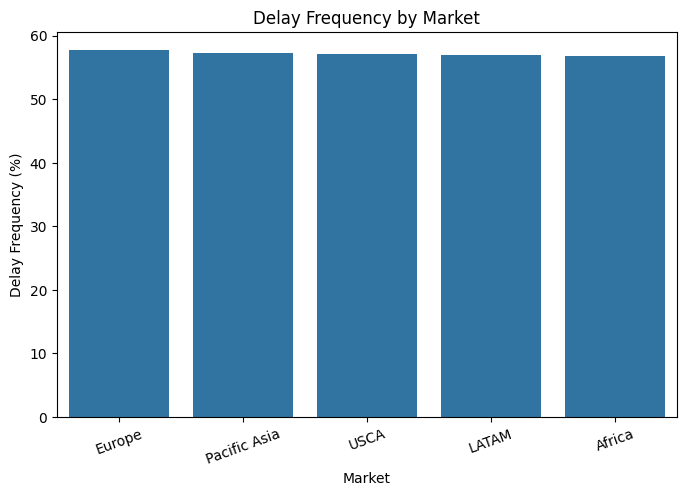

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=market_delay.reset_index(),
    x="Market",
    y="Delay Frequency (%)"
)

plt.title("Delay Frequency by Market")
plt.xlabel("Market")
plt.ylabel("Delay Frequency (%)")
plt.xticks(rotation=20)
plt.show()

In [68]:
top_regions = (
    region_delay
    .head(5)
    .reset_index()[[
        "Order Region",
        "Total_Shipments",
        "Delayed_Shipments",
        "Delay Frequency (%)"
    ]]
    .rename(columns={"Order Region": "Geography"})
)

top_regions["Level"] = "Region"


top_countries = (
    country_delay
    .head(5)
    .reset_index()[[
        "Order Country",
        "Total_Shipments",
        "Delayed_Shipments",
        "Delay Frequency (%)"
    ]]
    .rename(columns={"Order Country": "Geography"})
)

top_countries["Level"] = "Country"


top_markets = (
    market_delay
    .head(5)
    .reset_index()[[
        "Market",
        "Total_Shipments",
        "Delayed_Shipments",
        "Delay Frequency (%)"
    ]]
    .rename(columns={"Market": "Geography"})
)

top_markets["Level"] = "Market"


high_risk_geographies = pd.concat(
    [top_regions, top_countries, top_markets],
    ignore_index=True
)

high_risk_geographies = high_risk_geographies[
    [
        "Level",
        "Geography",
        "Total_Shipments",
        "Delayed_Shipments",
        "Delay Frequency (%)"
    ]
]

high_risk_geographies

,Level,Geography,Total_Shipments,Delayed_Shipments,Delay Frequency (%)
0,Region,Central Africa,1677,1018,60.70
1,Region,Western Europe,27107,15862,58.52
2,Region,South Asia,7730,4523,58.51
3,Region,South of USA,4045,2350,58.10
4,Region,Southeast Asia,9535,5529,57.99
5,Country,Bután,5,5,100.00
6,Country,Armenia,5,5,100.00
7,Country,Guinea Ecuatorial,2,2,100.00
8,Country,Eritrea,2,2,100.00
9,Country,República de Gambia,5,5,100.00


In [69]:
customer_segment_delay = (
    df.groupby("Customer Segment")
    .agg(
        Total_Shipments=("Customer Segment", "size"),
        Delayed_Shipments=(
            "Delivery Timing",
            lambda x: (x == "Delayed").sum()
        )
    )
)

In [70]:
customer_segment_delay["Delay Frequency (%)"] = (
    customer_segment_delay["Delayed_Shipments"]
    / customer_segment_delay["Total_Shipments"]
    * 100
)

In [71]:
customer_segment_delay = (
    customer_segment_delay
    .sort_values("Delay Frequency (%)", ascending=False)
    .round(2)
)

customer_segment_delay

,Total_Shipments,Delayed_Shipments,Delay Frequency (%)
Customer Segment,,,
Home Office,32223,18535,57.52
Consumer,93501,53572,57.30
Corporate,54784,31288,57.11


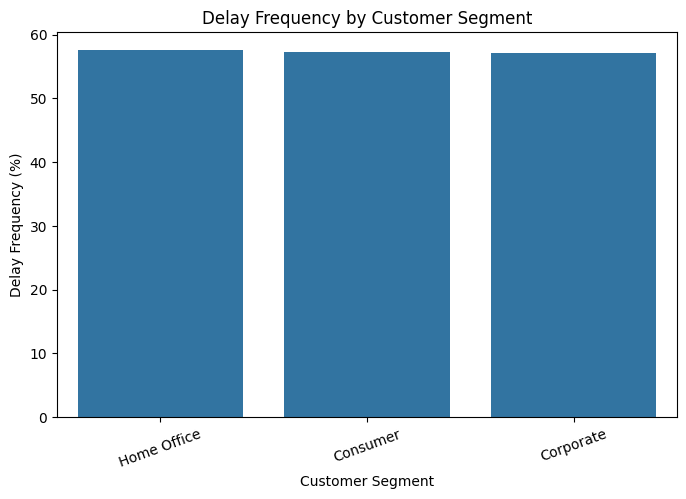

In [72]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_segment_delay.reset_index(),
    x="Customer Segment",
    y="Delay Frequency (%)"
)

plt.title("Delay Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Delay Frequency (%)")
plt.xticks(rotation=20)
plt.show()

In [73]:
customer_segment_impact = (
    df.groupby("Customer Segment")
    .agg(
        Total_Shipments=("Customer Segment", "size"),
        Average_Delay_Days=("Delay Gap", "mean"),
        Delayed_Shipments=("Delivery Timing", lambda x: (x == "Delayed").sum()),
        Late_Risk_Rate=("Late_delivery_risk", "mean")
    )
)

In [74]:
customer_segment_impact["Delay Frequency (%)"] = (
    customer_segment_impact["Delayed_Shipments"]
    / customer_segment_impact["Total_Shipments"] * 100
)

In [75]:
customer_segment_impact["Late Risk (%)"] = (
    customer_segment_impact["Late_Risk_Rate"] * 100
)

In [76]:
customer_segment_impact = (
    customer_segment_impact[
        [
            "Total_Shipments",
            "Delayed_Shipments",
            "Average_Delay_Days",
            "Delay Frequency (%)",
            "Late Risk (%)"
        ]
    ]
    .sort_values("Delay Frequency (%)", ascending=False)
    .round(2)
)

customer_segment_impact

,Total_Shipments,Delayed_Shipments,Average_Delay_Days,Delay Frequency (%),Late Risk (%)
Customer Segment,,,,,
Home Office,32223,18535,0.58,57.52,55.07
Consumer,93501,53572,0.56,57.30,54.81
Corporate,54784,31288,0.56,57.11,54.72


In [77]:
sla_risk_exposure = (
    df.groupby("Customer Segment")
    .agg(
        Total_Shipments=("Customer Segment", "size"),
        At_Risk_Shipments=("Late_delivery_risk", "sum")
    )
)

In [78]:
sla_risk_exposure["SLA Risk Exposure (%)"] = (
    sla_risk_exposure["At_Risk_Shipments"]
    / sla_risk_exposure["Total_Shipments"] * 100
)

In [80]:
sla_risk_exposure = (
    sla_risk_exposure
    .sort_values("SLA Risk Exposure (%)", ascending=False)
    .round(2)
)

sla_risk_exposure

,Total_Shipments,At_Risk_Shipments,SLA Risk Exposure (%)
Customer Segment,,,
Home Office,32223,17746,55.07
Consumer,93501,51247,54.81
Corporate,54784,29979,54.72


In [81]:
on_time_delivery_rate = (
    (df["Delivery Timing"] == "On-time").mean() * 100
)

print(f"On-Time Delivery Rate: {on_time_delivery_rate:.2f}%")

On-Time Delivery Rate: 18.70%


In [82]:
average_delivery_delay = df["Delay Gap"].mean()

print(f"Average Delivery Delay: {average_delivery_delay:.2f} days")

Average Delivery Delay: 0.57 days


In [83]:
late_delivery_risk_ratio = df["Late_delivery_risk"].mean()

print(f"Late Delivery Risk Ratio: {late_delivery_risk_ratio:.2%}")

Late Delivery Risk Ratio: 54.83%


In [84]:
shipping_mode_efficiency = (
    df.groupby("Shipping Mode")["Delay Gap"]
    .mean()
    .sort_values()
    .round(2)
    .reset_index()
)

shipping_mode_efficiency.columns = [
    "Shipping Mode",
    "Average Delay (Days)"
]

shipping_mode_efficiency

,Shipping Mode,Average Delay (Days)
0,Standard Class,-0.00
1,Same Day,0.48
2,First Class,1.00
3,Second Class,1.99


In [85]:
regional_delay_index = (
    df.groupby("Order Region")["Delay Gap"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

regional_delay_index.columns = [
    "Order Region",
    "Regional Delay Index"
]

regional_delay_index

,Order Region,Regional Delay Index
0,Central Asia,0.65
1,Central Africa,0.64
2,South Asia,0.60
3,Western Europe,0.60
4,US Center,0.59
5,East of USA,0.58
6,South of USA,0.58
7,Eastern Europe,0.58
8,East Africa,0.57
9,West Asia,0.57


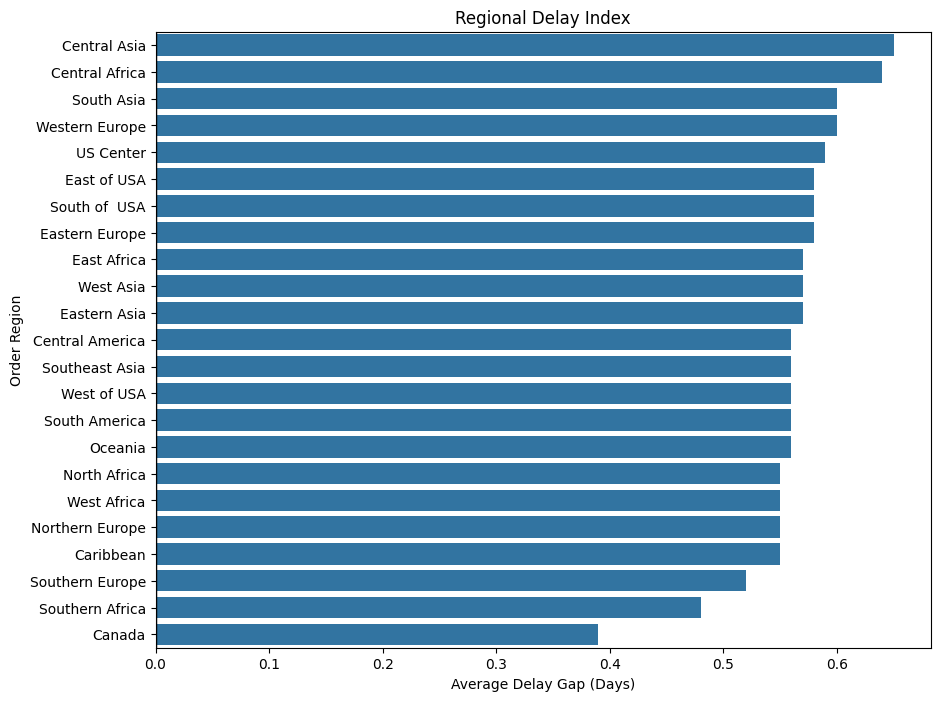

In [86]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=regional_delay_index,
    y="Order Region",
    x="Regional Delay Index"
)

plt.title("Regional Delay Index")
plt.xlabel("Average Delay Gap (Days)")
plt.ylabel("Order Region")
plt.axvline(0, color="black", linewidth=1)
plt.show()

In [87]:
kpi_summary = {
    "On-Time Delivery Rate (%)": round(on_time_delivery_rate, 2),
    "Average Delivery Delay (Days)": round(average_delivery_delay, 2),
    "Late Delivery Risk Ratio (%)": round(late_delivery_risk_ratio, 2)
}

kpi_summary_df = pd.DataFrame(
    kpi_summary.items(),
    columns=["KPI", "Value"]
)

kpi_summary_df

,KPI,Value
0,On-Time Delivery Rate (%),18.70
1,Average Delivery Delay (Days),0.57
2,Late Delivery Risk Ratio (%),0.55
